# Import Libraries


In [1]:
import numpy as np
from scipy.stats import t
import matplotlib.pyplot as plt

# Import Helper Functions


In [2]:
import permutation_func as hf
import plot as pl

updates


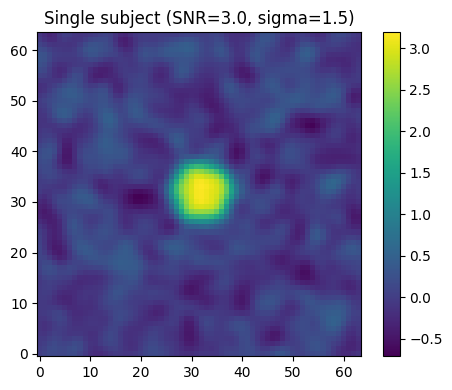

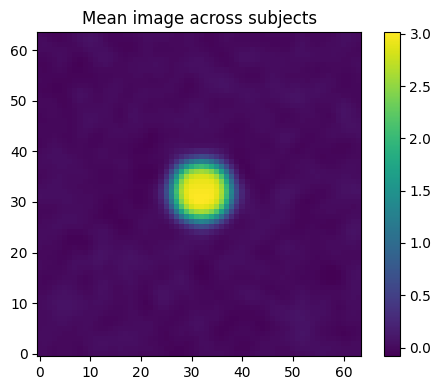

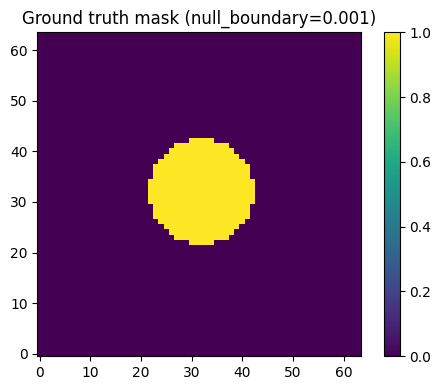

df = 49
cluster-forming t-threshold = 2.67995197363155
critical cluster size = 18
max cluster sizes (null) summary: min 2 median 10 max 197


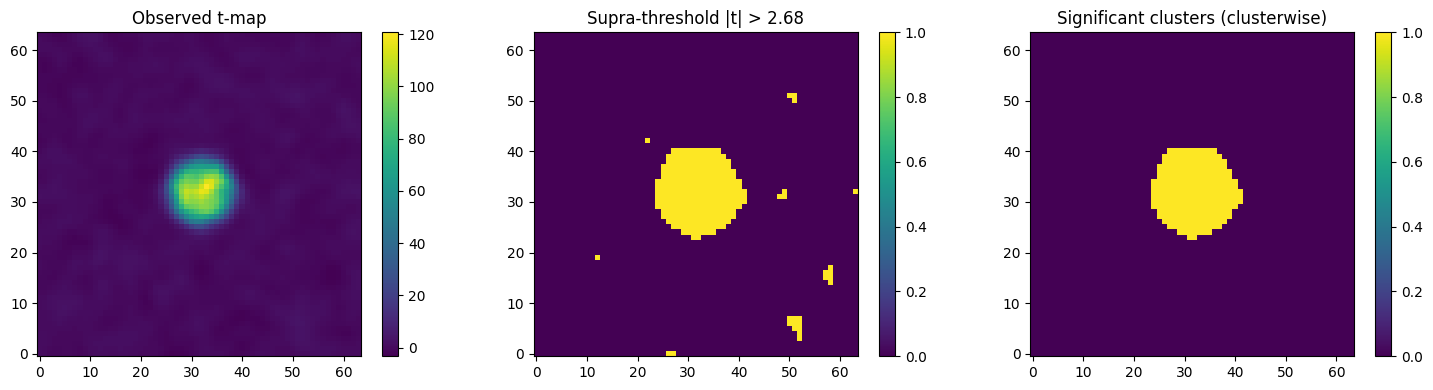

Sensitivity (TPR over truth mask) = 0.7243401759530792


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# --- Settings --
n_subj = 50
img_side_length = 64
smoothing_sigma = 1.5
alpha = 0.05
n_perm = 200
null_boundary = 1e-3

snr_demo = 3.0
signal_radius = 6
random_state = 0  # controls BOTH simulation + permutation RNG

# --- Simulate data (NEW VERSION) ---
data = hf.simulate_data(
    n_subj=n_subj,
    img_side=img_side_length,
    sigma=smoothing_sigma,
    snr=snr_demo,
    signal_radius=signal_radius,
    labels=False,            # one-sample
    random_state=random_state
)

# --- Quick visuals ---
plt.figure(figsize=(5,4))
plt.imshow(data[0], origin="lower")
plt.title(f"Single subject (SNR={snr_demo}, sigma={smoothing_sigma})")
plt.colorbar()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
plt.imshow(data.mean(axis=0), origin="lower")
plt.title("Mean image across subjects")
plt.colorbar()
plt.tight_layout()
plt.show()

# --- Ground truth mask (smoothed truth) ---
true_mask = hf.get_smoothed_truth_mask(
    img_side_length, img_side_length,
    sigma=smoothing_sigma,
    radius=signal_radius,
    null_boundary=null_boundary
)

plt.figure(figsize=(5,4))
plt.imshow(true_mask, origin="lower")
plt.title(f"Ground truth mask (null_boundary={null_boundary})")
plt.colorbar()
plt.tight_layout()
plt.show()

# --- Design / df ---
_, _, df = hf.build_design_matrix(n_subj, labels=False)

# cluster-forming threshold: p=0.01 two-sided
cluster_forming_thr = t.ppf(1 - 0.01/2, df)

# --- Clusterwise permutation test ---
tmap_obs, labeled_obs, sig_clusters_mask, crit_cluster_size, max_cluster_sizes, used_thr = (
    hf.clusterwise_permutation_test(
        data=data,
        labels=False,
        alpha=alpha,
        n_perm=n_perm,
        cluster_forming_thr=cluster_forming_thr,
        random_state=random_state
    )
)

print("df =", df)
print("cluster-forming t-threshold =", used_thr)
print("critical cluster size =", crit_cluster_size)
print(
    "max cluster sizes (null) summary:",
    "min", int(max_cluster_sizes.min()),
    "median", int(np.median(max_cluster_sizes)),
    "max", int(max_cluster_sizes.max())
)

# --- Show observed / supra-threshold / significant clusters ---
supra = (np.abs(tmap_obs) > used_thr)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(tmap_obs, origin="lower")
plt.title("Observed t-map")
plt.colorbar(fraction=0.046)

plt.subplot(1,3,2)
plt.imshow(supra, origin="lower")
plt.title(f"Supra-threshold |t| > {used_thr:.2f}")
plt.colorbar(fraction=0.046)

plt.subplot(1,3,3)
plt.imshow(sig_clusters_mask, origin="lower")
plt.title("Significant clusters (clusterwise)")
plt.colorbar(fraction=0.046)

plt.tight_layout()
plt.show()

# --- Sensitivity (TPR over truth mask) ---
tp = np.sum(sig_clusters_mask & true_mask)
total_true = np.sum(true_mask)
sensitivity = tp / total_true if total_true > 0 else 0.0
print("Sensitivity (TPR over truth mask) =", sensitivity)


In [4]:
import numpy as np
import pandas as pd
from scipy.stats import t

# grids
sigma_levels = [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
snr_levels   = [0, 0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0]
n_subj_levels = [2, 5, 7, 10, 15, 20, 30, 45, 60]

# match your friend's compute budget
n_runs = 20
n_perm = 50
alpha = 0.05

img_side = 64
signal_radius = 6
null_boundary = 1e-3


cdt_p = 0.001

rows = []
grid_index = 0
random_state_base = 0

for n_subj in n_subj_levels:
    df = n_subj - 1  # one-sample in your build_design_matrix
    cluster_forming_thr = float(t.ppf(1 - cdt_p/2, df))

    for sm_sigma in sigma_levels:
        for snr in snr_levels:
            grid_index += 1

            # vary base seed per gridpoint so you don't reuse the exact same run-seeds each time
            base = random_state_base + 10_000 * grid_index

            sens_mat, fwer_mat = hf.run_2d_sweep_clusterwise(
                n_runs=n_runs,
                n_subj=n_subj,
                img_side=img_side,
                snr_levels=[snr],
                sigma_levels=[sm_sigma],
                alpha=alpha,
                labels=False,  # one-sample
                signal_radius=signal_radius,
                n_perm=n_perm,
                null_boundary=null_boundary,
                cluster_forming_thr=cluster_forming_thr,
                random_state_base=base
            )

            rows.append({
                "fwer": float(fwer_mat[0, 0]),
                "sensitivity": float(sens_mat[0, 0]),
                "sm_sigma": float(sm_sigma),
                "snr": float(snr),
                "n_subj": int(n_subj),
                "method": "clusterwise_perm"
            })

df_out = pd.DataFrame(rows).sort_values(["n_subj", "sm_sigma", "snr"]).reset_index(drop=True)
df_out.to_csv("clusterwise_permutation_test_metrics.csv", index=False)
print(df_out.head(), "\nrows:", len(df_out))


   fwer  sensitivity  sm_sigma   snr  n_subj            method
0   0.0          0.0       0.0  0.00       2  clusterwise_perm
1   0.0          0.0       0.0  0.10       2  clusterwise_perm
2   0.0          0.0       0.0  0.25       2  clusterwise_perm
3   0.0          0.0       0.0  0.50       2  clusterwise_perm
4   0.0          0.0       0.0  0.75       2  clusterwise_perm 
rows: 1764


In [5]:
import numpy as np
from scipy.stats import t

n_subj = 50
img_side_length = 64
alpha = 0.05
null_boundary = 1e-3

# "Fast test"
n_runs = 20
n_perm = 50
signal_radius = 6

test_snrs =   [0, 0.1, 0.175, 0.25, 0.4, 0.5, 0.6, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.1, 2.25, 2.4, 2.5, 2.6, 2.75, 2.9, 3.0]
test_sigmas = [0, 0.1, 0.25, 0.175, 0.4, 0.5, 0.6, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.1, 2.25, 2.4, 2.5, 2.6, 2.75, 2.9, 3.0]

# df for one-sample
_, _, df = hf.build_design_matrix(n_subj, labels=False)

# cluster-forming threshold: p=0.01 (two-sided)
cluster_forming_thr = t.ppf(1 - 0.01/2, df)
cluster_forming_thr


np.float64(2.67995197363155)

In [6]:
sens_mat, fwer_mat = hf.run_2d_sweep_clusterwise(
    n_runs=n_runs,
    n_subj=n_subj,
    img_side=img_side_length,
    snr_levels=test_snrs,
    sigma_levels=test_sigmas,
    alpha=alpha,
    labels=False,                 # ONE-SAMPLE ONLY
    signal_radius=signal_radius,
    n_perm=n_perm,
    null_boundary=null_boundary,
    cluster_forming_thr=cluster_forming_thr,
    random_state_base=0
)

sens_mat.shape, fwer_mat.shape


((21, 21), (21, 21))

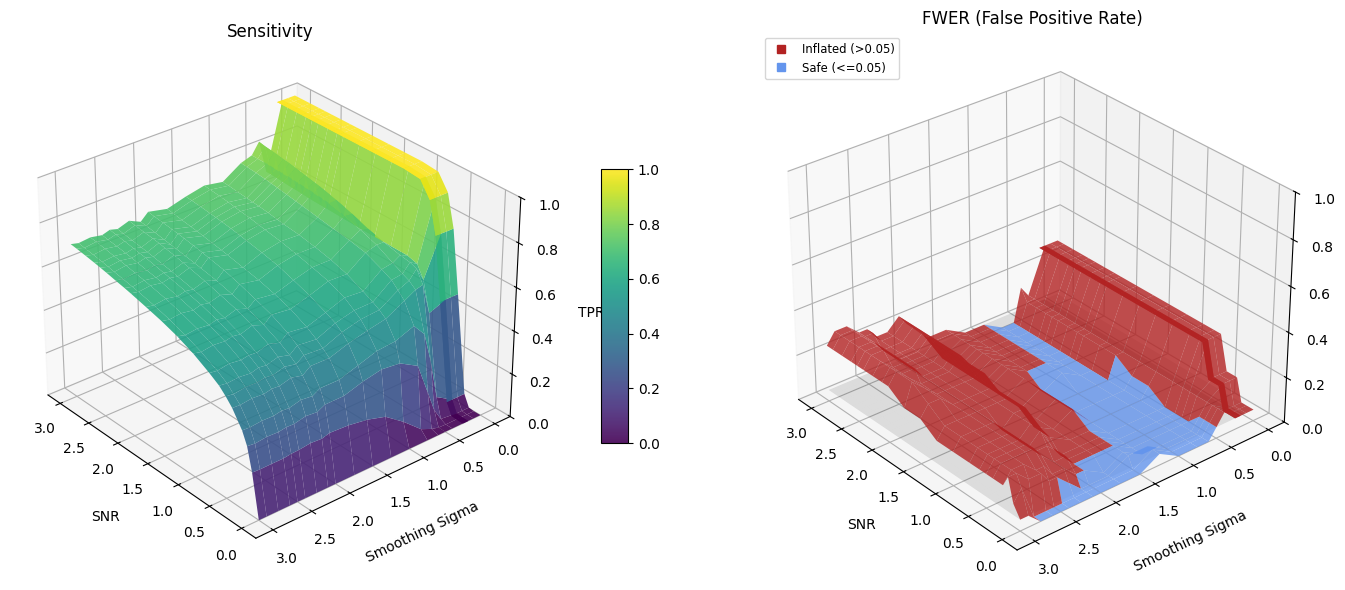

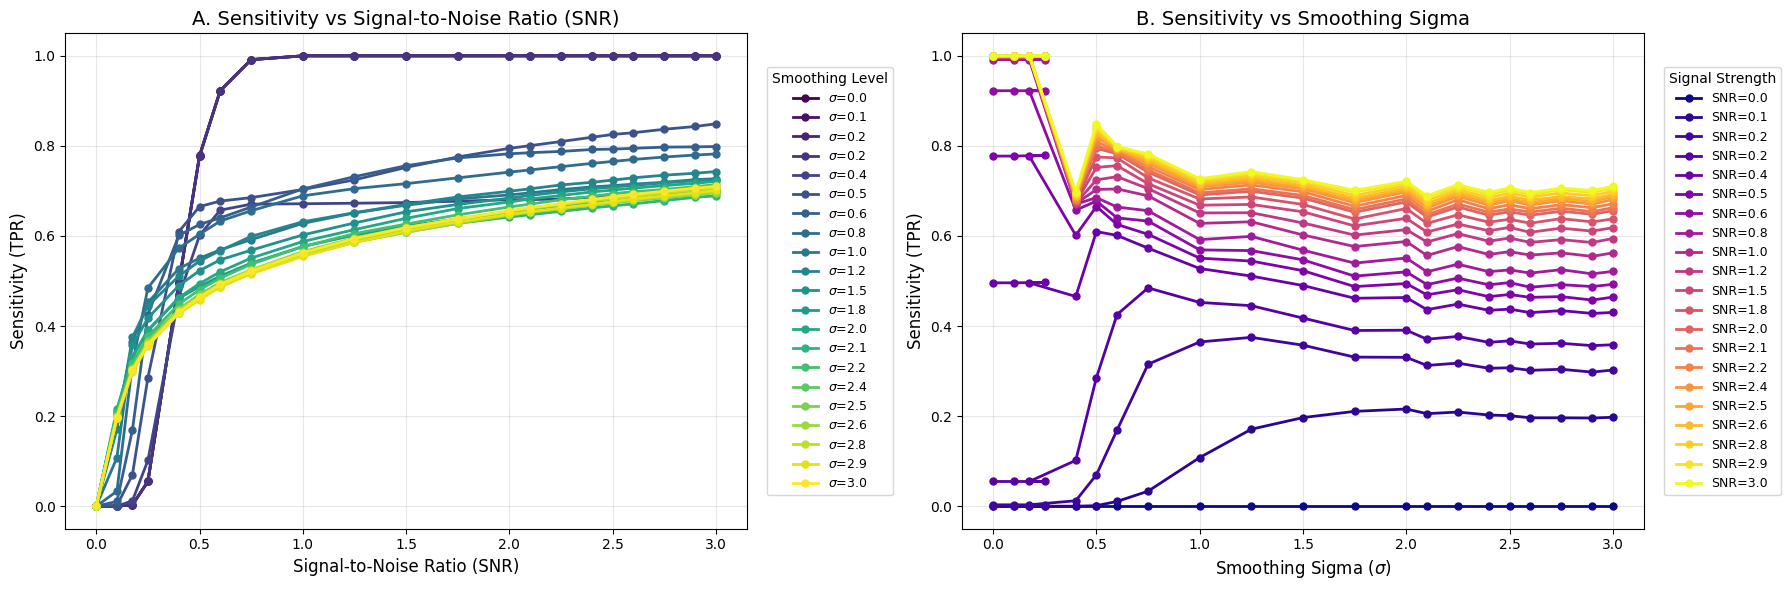

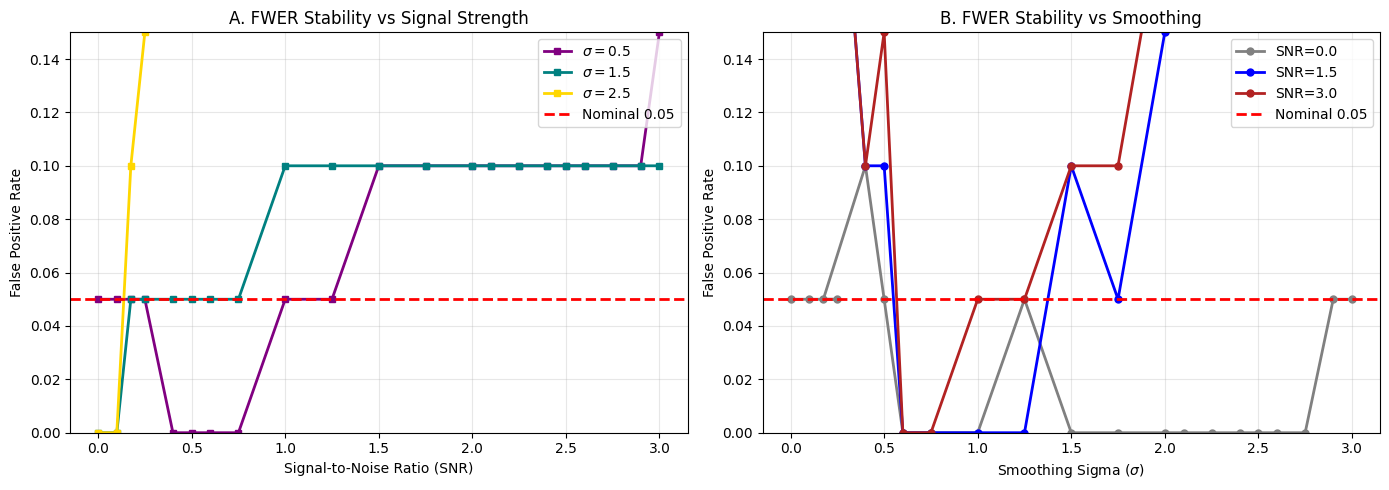

In [7]:
pl.plot_3d_surfaces(test_snrs, test_sigmas, sens_mat, fwer_mat, elev=30, azim=140)
pl.plot_sensitivity_analysis(test_snrs, test_sigmas, sens_mat)
pl.plot_fwer_stability(test_snrs, test_sigmas, fwer_mat, np.array(test_sigmas), np.array(test_snrs))


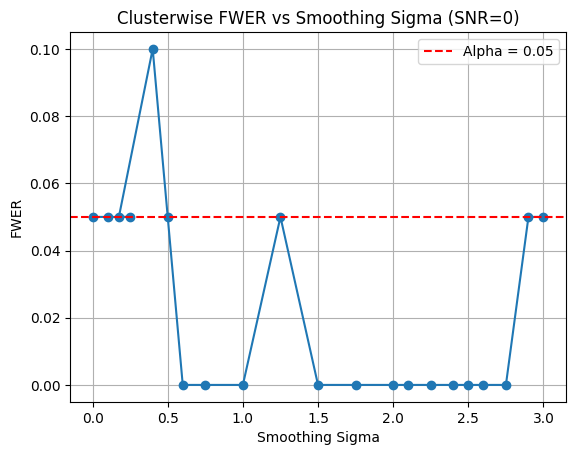

In [8]:
# Extract the SNR=0 column
snr0_idx = np.where(np.isclose(np.array(test_snrs), 0.0))[0][0]
fwer_snr0 = fwer_mat[:, snr0_idx]

plt.figure()
plt.plot(test_sigmas, fwer_snr0, marker='o')
plt.xlabel("Smoothing Sigma")
plt.ylabel("FWER")
plt.title("Clusterwise FWER vs Smoothing Sigma (SNR=0)")
plt.grid(True)
plt.axhline(y=0.05, linestyle='--', color='r', label='Alpha = 0.05')
plt.legend()
plt.show()


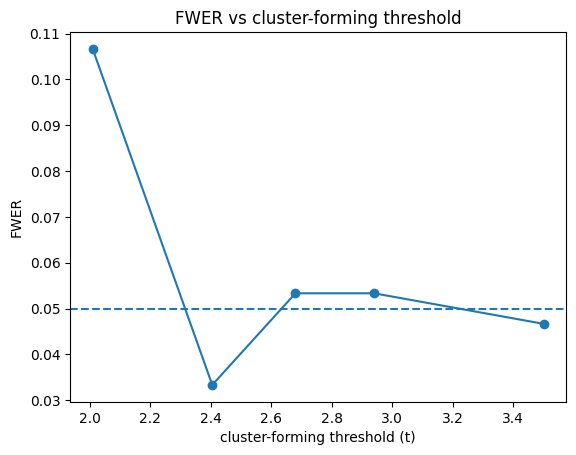

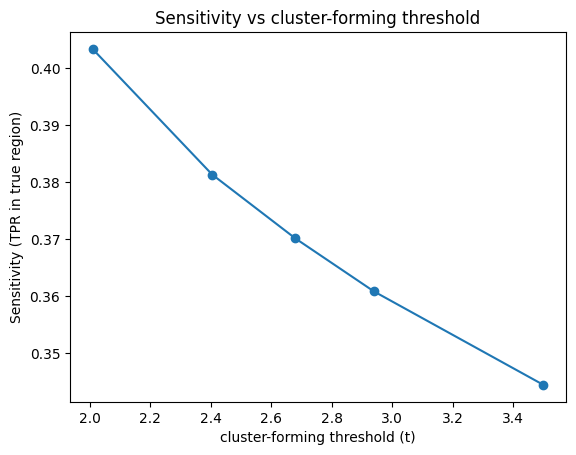

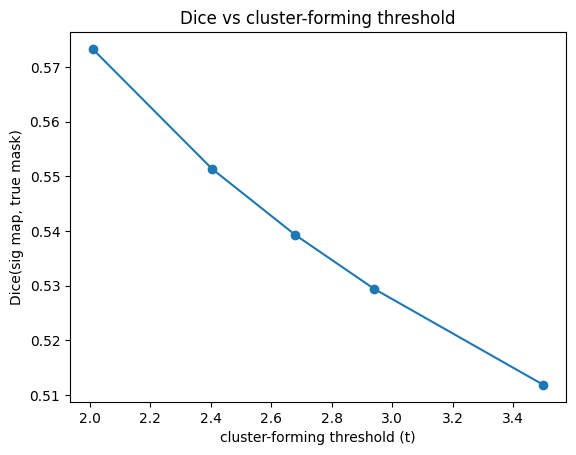

thr=2.010 | FWER=0.107 | Sens=0.403 | Dice=0.573
thr=2.405 | FWER=0.033 | Sens=0.381 | Dice=0.551
thr=2.680 | FWER=0.053 | Sens=0.370 | Dice=0.539
thr=2.940 | FWER=0.053 | Sens=0.361 | Dice=0.529
thr=3.500 | FWER=0.047 | Sens=0.344 | Dice=0.512


In [9]:
from scipy.stats import t as tdist
import matplotlib.pyplot as plt

n_subj = 50
labels = False
X, L, df = hf.build_design_matrix(n_subj, labels)

# Two-sided voxelwise thresholds:
p_list = [0.05, 0.02, 0.01, 0.005, 0.001]
thresholds = [tdist.ppf(1 - p/2, df) for p in p_list]

res = hf.run_threshold_sweep_clusterwise(
    n_runs=150,
    n_subj=n_subj,
    img_side=64,
    sigma=2.0,
    snr=1.0,
    alpha=0.05,
    thresholds=thresholds,
    labels=labels,
    signal_radius=6,
    n_perm=1000,
    random_state_base=123
)

plt.figure()
plt.plot(res["thr"], res["fwer"], marker="o")
plt.axhline(0.05, linestyle="--")
plt.xlabel("cluster-forming threshold (t)")
plt.ylabel("FWER")
plt.title("FWER vs cluster-forming threshold")
plt.show()

plt.figure()
plt.plot(res["thr"], res["sens"], marker="o")
plt.xlabel("cluster-forming threshold (t)")
plt.ylabel("Sensitivity (TPR in true region)")
plt.title("Sensitivity vs cluster-forming threshold")
plt.show()

plt.figure()
plt.plot(res["thr"], res["dice"], marker="o")
plt.xlabel("cluster-forming threshold (t)")
plt.ylabel("Dice(sig map, true mask)")
plt.title("Dice vs cluster-forming threshold")
plt.show()

# quick view
for thr, f, s, d in zip(res["thr"], res["fwer"], res["sens"], res["dice"]):
    print(f"thr={thr:.3f} | FWER={f:.3f} | Sens={s:.3f} | Dice={d:.3f}")


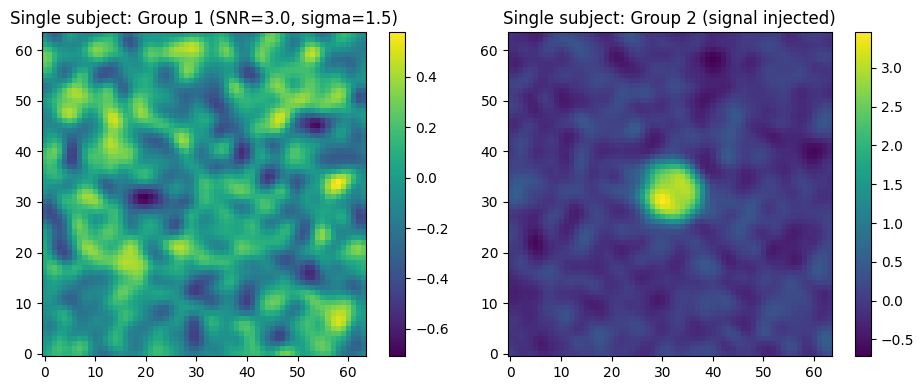

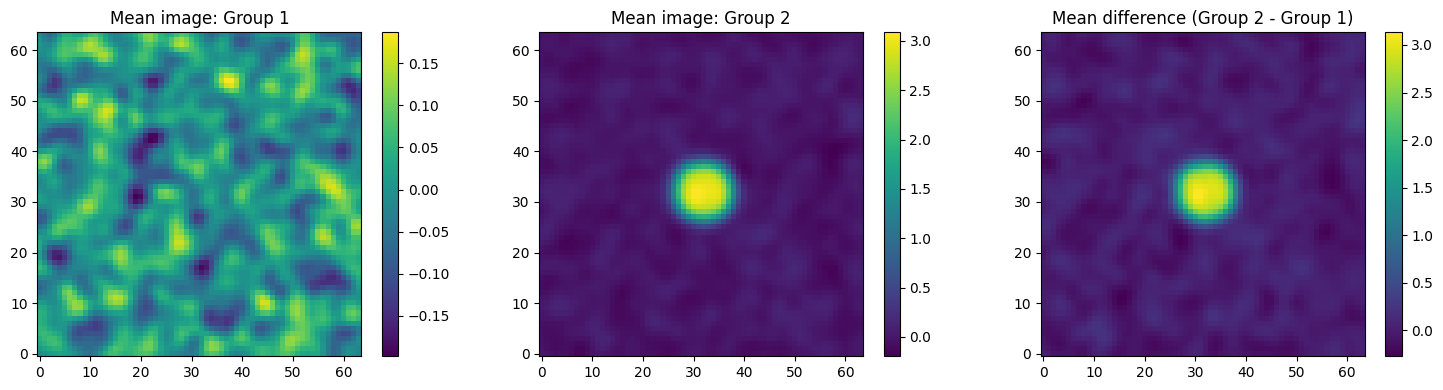

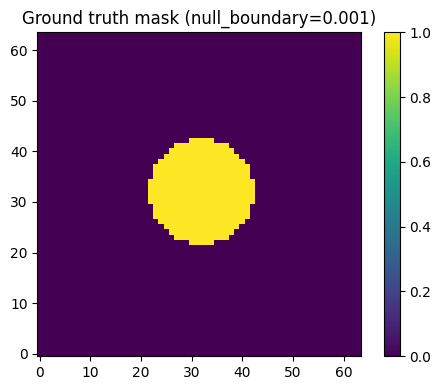

df = 18
cluster-forming t-threshold = 2.878440472713585
critical cluster size = 20
max cluster sizes (null) summary: min 2 median 9 max 191


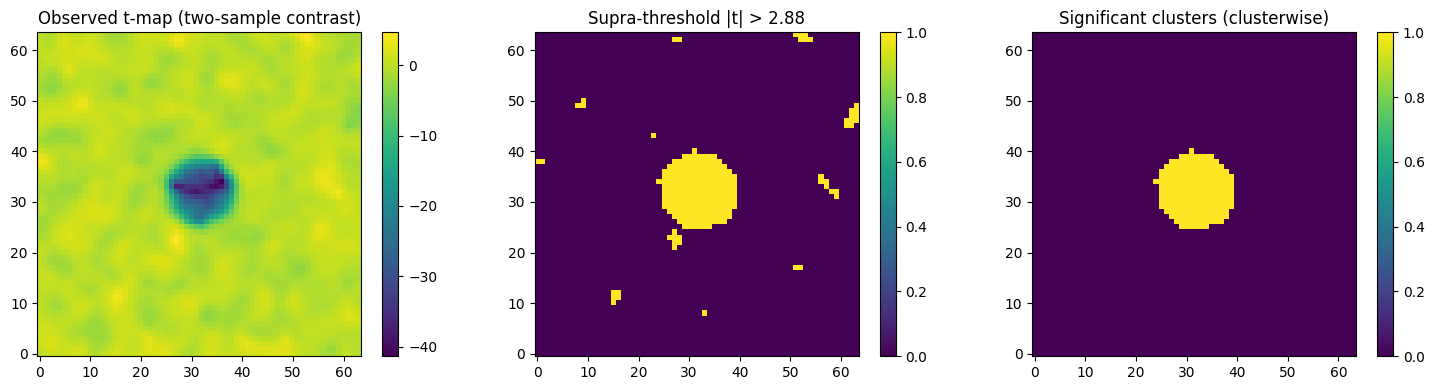

Sensitivity (TPR over truth mask) = 0.5601173020527859
Centre t-statistic = -36.54093578328961


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

# --- Settings ---
n_subj = 20
img_side_length = 64
smoothing_sigma = 1.5
alpha = 0.05
n_perm = 200
null_boundary = 1e-3

snr_demo = 3.0
signal_radius = 6
random_state = 0  # controls BOTH simulation + permutation RNG

labels = True  # <-- TWO-SAMPLE

# --- Simulate data (two-sample) ---
# group1: subjects 0..9   group2: subjects 10..19
# signal is injected into group2 only when labels=True
data = hf.simulate_data(
    n_subj=n_subj,
    img_side=img_side_length,
    sigma=smoothing_sigma,
    snr=snr_demo,
    signal_radius=signal_radius,
    labels=labels,           # <-- two-sample
    random_state=random_state
)

# --- Quick visuals ---
# Show one subject from each group so you can see the difference
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(data[0], origin="lower")
plt.title(f"Single subject: Group 1 (SNR={snr_demo}, sigma={smoothing_sigma})")
plt.colorbar(fraction=0.046)
plt.tight_layout()

plt.subplot(1,2,2)
plt.imshow(data[n_subj//2], origin="lower")
plt.title("Single subject: Group 2 (signal injected)")
plt.colorbar(fraction=0.046)
plt.tight_layout()
plt.show()

# Group means + difference (difference should highlight the signal)
g1_mean = data[:n_subj//2].mean(axis=0)
g2_mean = data[n_subj//2:].mean(axis=0)
diff_mean = g2_mean - g1_mean

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(g1_mean, origin="lower")
plt.title("Mean image: Group 1")
plt.colorbar(fraction=0.046)

plt.subplot(1,3,2)
plt.imshow(g2_mean, origin="lower")
plt.title("Mean image: Group 2")
plt.colorbar(fraction=0.046)

plt.subplot(1,3,3)
plt.imshow(diff_mean, origin="lower")
plt.title("Mean difference (Group 2 - Group 1)")
plt.colorbar(fraction=0.046)

plt.tight_layout()
plt.show()

# --- Ground truth mask (smoothed truth) ---
# NOTE: for a two-sample "difference" truth, this mask still marks where the effect exists spatially.
true_mask = hf.get_smoothed_truth_mask(
    img_side_length, img_side_length,
    sigma=smoothing_sigma,
    radius=signal_radius,
    null_boundary=null_boundary
)

plt.figure(figsize=(5,4))
plt.imshow(true_mask, origin="lower")
plt.title(f"Ground truth mask (null_boundary={null_boundary})")
plt.colorbar()
plt.tight_layout()
plt.show()

# --- Design / df ---
X, L, df = hf.build_design_matrix(n_subj, labels=labels)

# cluster-forming threshold: p=0.01 two-sided
cluster_forming_thr = t.ppf(1 - 0.01/2, df)

# --- Clusterwise permutation test (two-sample uses row permutations) ---
tmap_obs, labeled_obs, sig_clusters_mask, crit_cluster_size, max_cluster_sizes, used_thr = (
    hf.clusterwise_permutation_test(
        data=data,
        labels=labels,                   # <-- two-sample branch (permutation, not sign flip)
        alpha=alpha,
        n_perm=n_perm,
        cluster_forming_thr=cluster_forming_thr,
        random_state=random_state
    )
)

print("df =", df)
print("cluster-forming t-threshold =", used_thr)
print("critical cluster size =", crit_cluster_size)
print(
    "max cluster sizes (null) summary:",
    "min", int(max_cluster_sizes.min()),
    "median", int(np.median(max_cluster_sizes)),
    "max", int(max_cluster_sizes.max())
)

# --- Show observed / supra-threshold / significant clusters ---
supra = (np.abs(tmap_obs) > used_thr)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(tmap_obs, origin="lower")
plt.title("Observed t-map (two-sample contrast)")
plt.colorbar(fraction=0.046)

plt.subplot(1,3,2)
plt.imshow(supra, origin="lower")
plt.title(f"Supra-threshold |t| > {used_thr:.2f}")
plt.colorbar(fraction=0.046)

plt.subplot(1,3,3)
plt.imshow(sig_clusters_mask, origin="lower")
plt.title("Significant clusters (clusterwise)")
plt.colorbar(fraction=0.046)

plt.tight_layout()
plt.show()

# --- Sensitivity (TPR over truth mask) ---
# This measures how much of the true signal region is covered by significant voxels.
tp = np.sum(sig_clusters_mask & true_mask)
total_true = np.sum(true_mask)
sensitivity = tp / total_true if total_true > 0 else 0.0
print("Sensitivity (TPR over truth mask) =", sensitivity)

# --- Optional: sanity check the sign of the effect ---
# In your build_design_matrix you use L=[1, -1] (Group1 - Group2),
# so if Group2 > Group1, the centre t-stat is usually NEGATIVE.
cx = cy = img_side_length // 2
print("Centre t-statistic =", float(tmap_obs[cx, cy]))


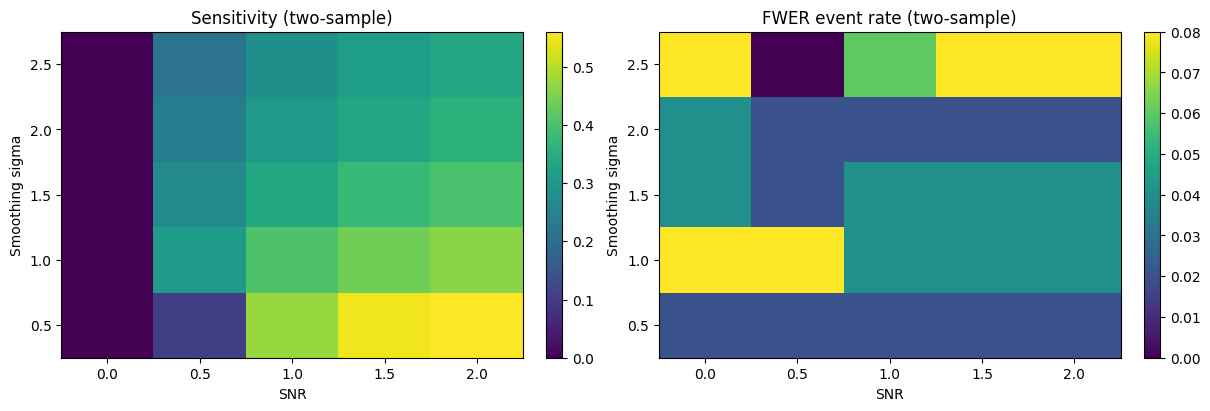

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# ---- choose sweep settings ----
n_runs = 50
n_subj = 20
img_side = 64
alpha = 0.05
labels = True          # <-- two-sample
signal_radius = 6
n_perm = 1000

snr_levels   = np.array([0.0, 0.5, 1.0, 1.5, 2.0])
sigma_levels = np.array([0.5, 1.0, 1.5, 2.0, 2.5])

sens_mat, fwer_mat = hf.run_2d_sweep_clusterwise(
    n_runs=n_runs,
    n_subj=n_subj,
    img_side=img_side,
    snr_levels=snr_levels,
    sigma_levels=sigma_levels,
    alpha=alpha,
    labels=labels,
    signal_radius=signal_radius,
    n_perm=n_perm,
    random_state_base=0,
)

# ---- plot heatmaps ----
fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

im0 = ax[0].imshow(sens_mat, origin="lower", aspect="auto")
ax[0].set_title("Sensitivity (two-sample)")
ax[0].set_xticks(np.arange(len(snr_levels))); ax[0].set_xticklabels(snr_levels)
ax[0].set_yticks(np.arange(len(sigma_levels))); ax[0].set_yticklabels(sigma_levels)
ax[0].set_xlabel("SNR"); ax[0].set_ylabel("Smoothing sigma")
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(fwer_mat, origin="lower", aspect="auto")
ax[1].set_title("FWER event rate (two-sample)")
ax[1].set_xticks(np.arange(len(snr_levels))); ax[1].set_xticklabels(snr_levels)
ax[1].set_yticks(np.arange(len(sigma_levels))); ax[1].set_yticklabels(sigma_levels)
ax[1].set_xlabel("SNR"); ax[1].set_ylabel("Smoothing sigma")
plt.colorbar(im1, ax=ax[1])

plt.show()


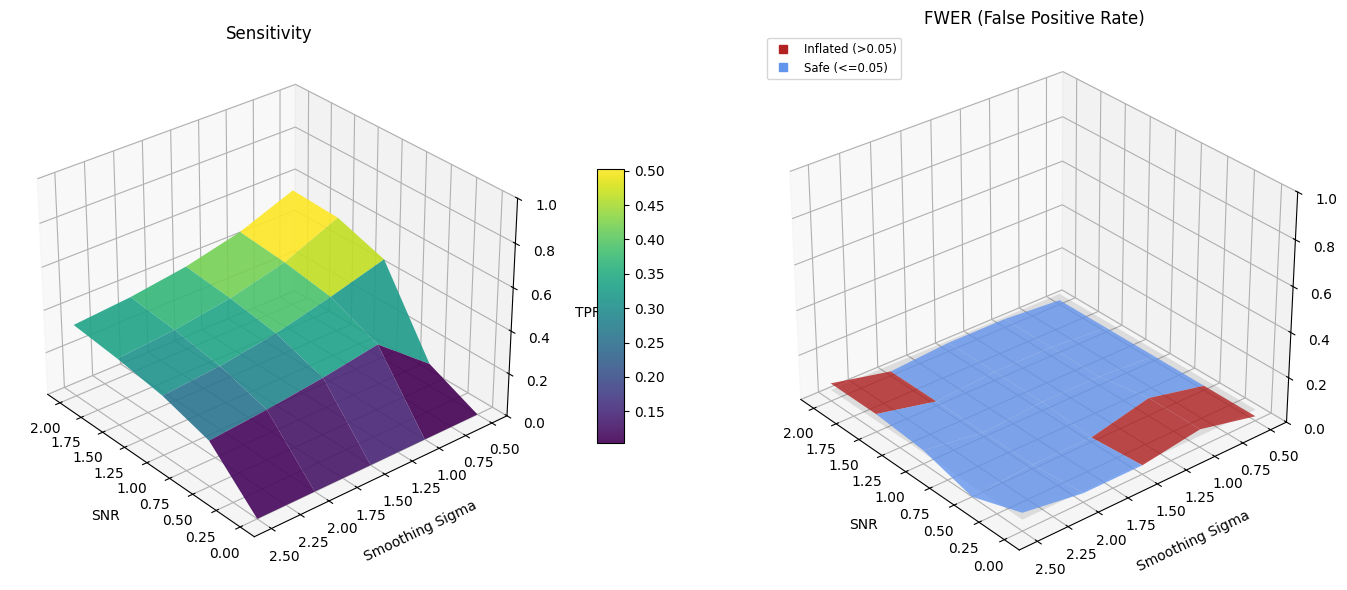

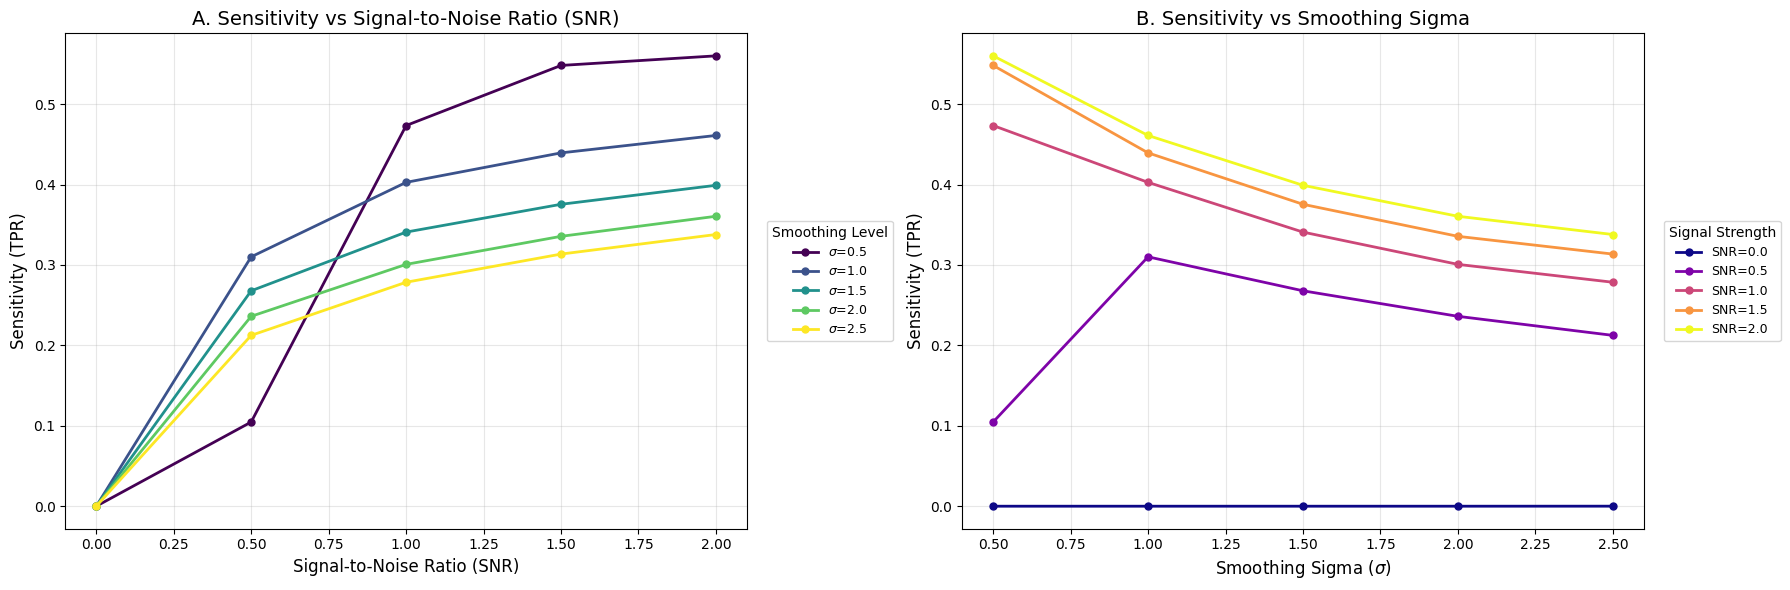

C:\Users\amari\PycharmProjects\group_project\Cluster_wise_permutation\plot.py:146: SyntaxWarning: invalid escape sequence '\s'
  ax_right.set_title(f"Observed Data (SNR={snr})\nSmoothed ($\sigma$={sigma}) + Noise", fontsize=11)
C:\Users\amari\PycharmProjects\group_project\Cluster_wise_permutation\plot.py:176: SyntaxWarning: invalid escape sequence '\s'
  color=colors[k], label=f'$\sigma={target}$')
C:\Users\amari\PycharmProjects\group_project\Cluster_wise_permutation\plot.py:198: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_xlabel("Smoothing Sigma ($\sigma$)")
C:\Users\amari\PycharmProjects\group_project\Cluster_wise_permutation\plot.py:222: SyntaxWarning: invalid escape sequence '\s'
  label=f'$\sigma$={sig_val:.1f}', color=colors_sig[i], linewidth=2)
C:\Users\amari\PycharmProjects\group_project\Cluster_wise_permutation\plot.py:239: SyntaxWarning: invalid escape sequence '\s'
  ax2.set_xlabel("Smoothing Sigma ($\sigma$)", fontsize=12)


IndexError: index 0 is out of bounds for axis 0 with size 0

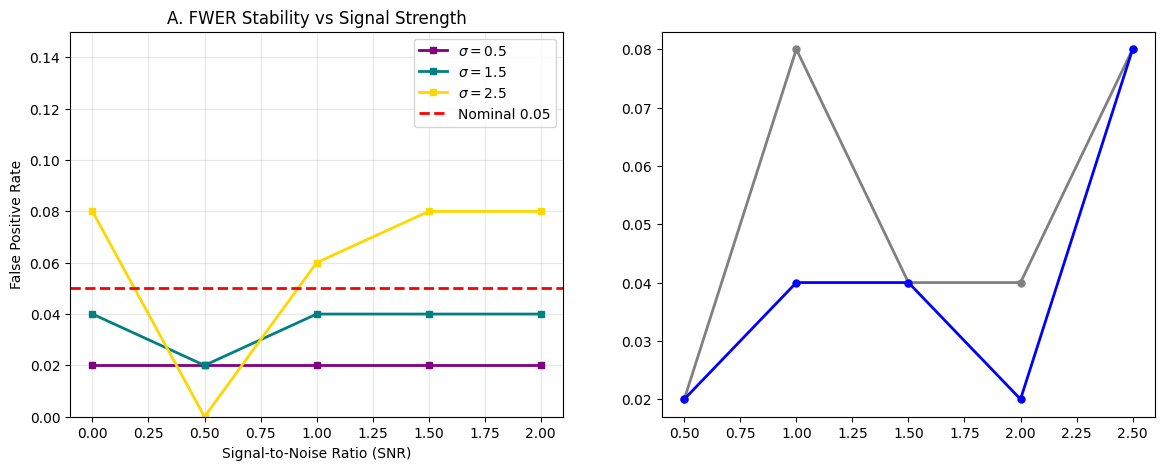

In [12]:
pl.plot_3d_surfaces(snr_levels, sigma_levels, sens_mat, fwer_mat, elev=30, azim=140)
pl.plot_sensitivity_analysis(snr_levels, sigma_levels, sens_mat)
pl.plot_fwer_stability(snr_levels, sigma_levels, fwer_mat, np.array(sigma_levels), np.array(snr_levels))


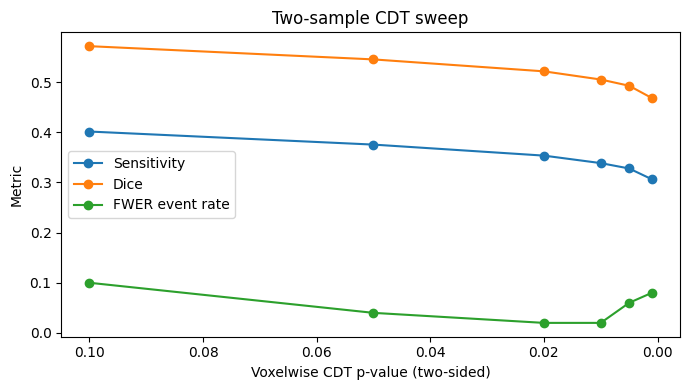

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ---- two-sample settings ----
n_runs = 50
n_subj = 20
img_side = 64
sigma = 1.5
snr = 1.5
alpha = 0.05
labels = True
signal_radius = 6
n_perm = 1000

# convert voxelwise p(CDT) -> t threshold
X, L, df = hf.build_design_matrix(n_subj, labels=True)
cdt_pvals = np.array([0.10, 0.05, 0.02, 0.01, 0.005, 0.001])
thresholds = np.array([hf.parametric_threshold(df, alpha=p) for p in cdt_pvals])

out = hf.run_threshold_sweep_clusterwise(
    n_runs=n_runs,
    n_subj=n_subj,
    img_side=img_side,
    sigma=sigma,
    snr=snr,
    alpha=alpha,
    thresholds=thresholds,
    labels=labels,
    signal_radius=signal_radius,
    n_perm=n_perm,
    random_state_base=0,
)

# ---- plot vs CDT p-values (more interpretable than t-values) ----
plt.figure(figsize=(7,4))
plt.plot(cdt_pvals, out["sens"], marker="o", label="Sensitivity")
plt.plot(cdt_pvals, out["dice"], marker="o", label="Dice")
plt.plot(cdt_pvals, out["fwer"], marker="o", label="FWER event rate")
plt.gca().invert_xaxis()  # smaller p = stricter CDT
plt.xlabel("Voxelwise CDT p-value (two-sided)")
plt.ylabel("Metric")
plt.title("Two-sample CDT sweep")
plt.legend()
plt.tight_layout()
plt.show()


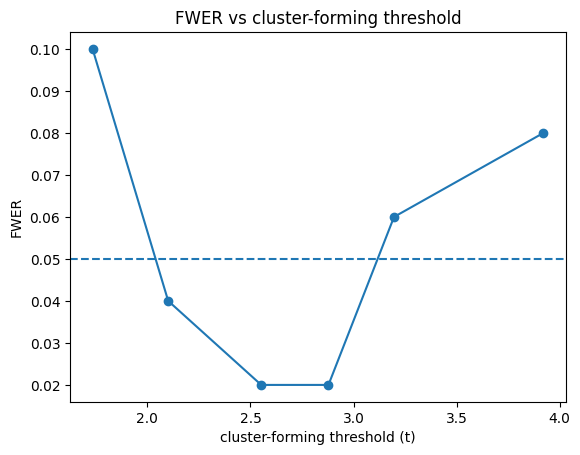

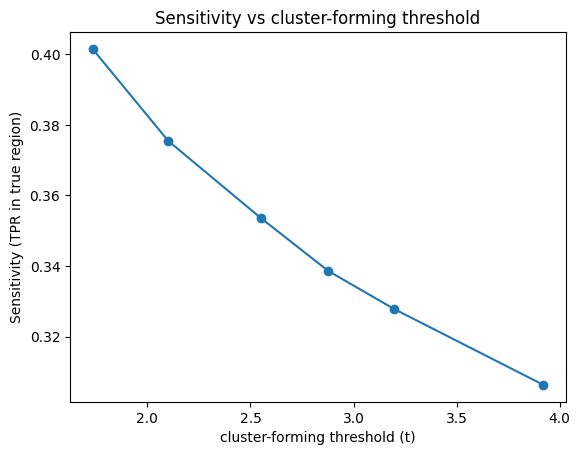

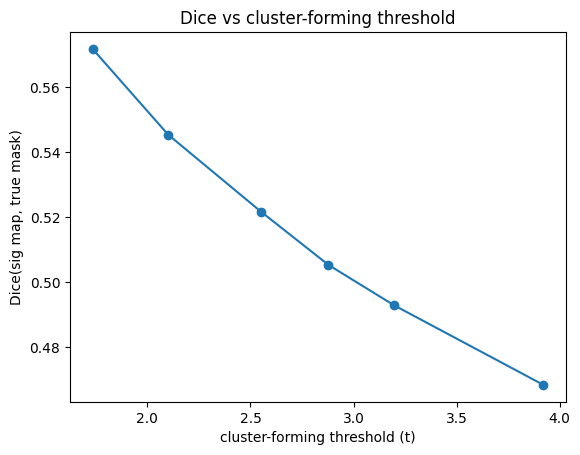

thr=1.734 | FWER=0.100 | Sens=0.402 | Dice=0.572
thr=2.101 | FWER=0.040 | Sens=0.375 | Dice=0.545
thr=2.552 | FWER=0.020 | Sens=0.354 | Dice=0.522
thr=2.878 | FWER=0.020 | Sens=0.339 | Dice=0.505
thr=3.197 | FWER=0.060 | Sens=0.328 | Dice=0.493
thr=3.922 | FWER=0.080 | Sens=0.306 | Dice=0.468


In [14]:
plt.figure()
plt.plot(out["thr"], out["fwer"], marker="o")
plt.axhline(0.05, linestyle="--")
plt.xlabel("cluster-forming threshold (t)")
plt.ylabel("FWER")
plt.title("FWER vs cluster-forming threshold")
plt.show()

plt.figure()
plt.plot(out["thr"], out["sens"], marker="o")
plt.xlabel("cluster-forming threshold (t)")
plt.ylabel("Sensitivity (TPR in true region)")
plt.title("Sensitivity vs cluster-forming threshold")
plt.show()

plt.figure()
plt.plot(out["thr"], out["dice"], marker="o")
plt.xlabel("cluster-forming threshold (t)")
plt.ylabel("Dice(sig map, true mask)")
plt.title("Dice vs cluster-forming threshold")
plt.show()

# quick view
for thr, f, s, d in zip(out["thr"], out["fwer"], out["sens"], out["dice"]):
    print(f"thr={thr:.3f} | FWER={f:.3f} | Sens={s:.3f} | Dice={d:.3f}")
